<u><b><h1 style="text-align:center; line-height:25px; color:#000000; background:#EFEFEF; border: 1px solid #FF6B6B ; padding:20px;">Sentiment analysis of customer reviews</h1></b></u>
**Course:** (DLBDSEAIS – Project: Artificial Intelligence  
**Tools**: Pandas, scikit-learn for the TF-IDF baseline, Hugging Face transformers (with PyTorch) for DistilBERT and Gradio for the interface  
**Dataset:** <a href="https://www.kaggle.com/datasets/fawadhossaini1415/amazon-fashion-800k-user-reviews-dataset">Amazon Fashion Products Reviews</a>  
**<a href="https://github.com/davidlupau/sentiment-analysis-customer-reviews">GitHub repository</a>**

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Setup & Imports</h2></b>

In [ ]:
# Core
import re
import time
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

print("Import successful")

### Select device
Select the compute backend automatically so the notebook runs unchanged on a cloud GPU (CUDA), an Apple Silicon Mac (MPS), or any CPU-only machine.

In [ ]:
def detect_device() -> torch.device:
    """Detect the best available compute device.

    Checks hardware availability in order of preference:
      1. CUDA  – NVIDIA GPU (fastest for most deep-learning workloads).
      2. MPS   – Apple Silicon GPU (Metal Performance Shaders).
      3. CPU   – universal fallback.

    Returns:
        torch.device: The most capable device available on this machine.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = detect_device()
RANDOM_STATE = 42
SAMPLES_PER_CLASS = 5_000
TFIDF_MAX_FEATURES = 10_000
TFIDF_NGRAM_RANGE = (1, 2)

# DistilBERT champion
DISTILBERT_MODEL = "distilbert-base-uncased"
NUM_EPOCHS = 3
MAX_TOKEN_LENGTH = 256
BATCH_SIZE = 16
LABEL_TO_ID = {"negative": 0, "neutral": 1, "positive": 2}
ID_TO_LABEL = {0: "negative", 1: "neutral", 2: "positive"}

# DistilBERT model persistence
MODEL_SAVE_DIR = "saved_model"

print(f"Device            : {DEVICE}")
print(f"Platform          : {platform.platform()}")
print(f"PyTorch           : {torch.__version__}")
print(f"Random state      : {RANDOM_STATE}")
print(f"Samples per class : {SAMPLES_PER_CLASS:,}")
print(f"TF-IDF features   : {TFIDF_MAX_FEATURES:,}")
print(f"TF-IDF n-grams    : {TFIDF_NGRAM_RANGE}")
print(f"DistilBERT model  : {DISTILBERT_MODEL}")
print(f"Epochs            : {NUM_EPOCHS}")
print(f"Max token length  : {MAX_TOKEN_LENGTH}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Model save dir    : {MODEL_SAVE_DIR}")

### Loading the dataset

In [11]:
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data").is_dir()
)

df = pd.read_csv(PROJECT_ROOT / "data" / "amazon-fashion-reviews-dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


### Data cleaning

In [12]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Remove unusable rows from the dataset.

    Drops rows where 'text' or 'rating' contain null values, then removes
    exact duplicate rows. Reports counts at each step.

    Args:
        df: Raw DataFrame loaded from the CSV file.

    Returns:
        pd.DataFrame: Cleaned DataFrame with nulls and duplicates removed.
    """
    initial_rows = len(df)
    print(f"Initial row count: {initial_rows:,}")

    null_mask = df[["text", "rating"]].isnull().any(axis=1)
    null_count = int(null_mask.sum())
    if null_count:
        print(f"Dropping {null_count:,} rows with null values in 'text' or 'rating'.")
        df = df[~null_mask]
    else:
        print("No null values found in 'text' or 'rating'.")

    duplicate_count = int(df.duplicated().sum())
    if duplicate_count:
        print(f"Dropping {duplicate_count:,} duplicate rows.")
        df = df.drop_duplicates()
    else:
        print("No duplicate rows found.")

    cleaned_rows = len(df)
    print(f"Final row count: {cleaned_rows:,} ({initial_rows - cleaned_rows:,} rows removed).\n")

    return df.reset_index(drop=True)


df = clean_dataset(df)

Initial row count: 867,310
Dropping 298 rows with null values in 'text' or 'rating'.
Dropping 5,264 duplicate rows.
Final row count: 861,748 (5,562 rows removed).



### Rating to sentiment mapping

In [13]:
def map_rating_to_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """Add a 'sentiment' column derived from the 'rating' column.

    Mapping:
        1, 2  → negative
        3     → neutral
        4, 5  → positive
    """
    mapping = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}
    df = df.copy()
    df["sentiment"] = df["rating"].map(mapping)
    counts = df["sentiment"].value_counts()
    print("Sentiment distribution:")
    for label in ["positive", "neutral", "negative"]:
        print(f"  {label}: {counts.get(label, 0):,}")
    print()
    return df


df = map_rating_to_sentiment(df)
df.head()

Sentiment distribution:
  positive: 345,569
  neutral: 172,247
  negative: 343,932



,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchases,target,sentiment
0,1.0,It say 5 pair when purchasing but only get 2 r...,I was looking for 5 pair and only received 2 p...,[],B07QFTMTLP,B07QFTMTLP,AHASEZ65RESN57BMGRV6QBM5DTIA,1565088068852,0,True,-1,negative
1,1.0,DonÃ¢ÂÂt do it!,Just donÃ¢ÂÂt. These things fell apart after...,[],B0764KKDN1,B0764KKDN1,AE3AMA3QSOHFKV46JJAHTHMMIR6A,1622416429592,0,True,-1,negative
2,1.0,Small,Retuned is too small for me,[],B07J1WHVCP,B07J1WHVCP,AH4CFWQE2HTC5BSWIEF3LVLUFK6A,1565284666220,0,True,-1,negative
3,1.0,Pre-Used When Received,This product came with the sleeves turned insi...,[],B0773JWP64,B0773JWP64,AFEKQFJWST6MVTKEJBQKUUBTWK7A,1581963636172,0,False,-1,negative
4,1.0,Worn once and several places at seams have com...,Worn once and several places at seams have com...,[],B099NST9RX,B08JGNS1NK,AGU2FPKN6ARXUSSGBT6WTVLZKJSQ,1640895438476,0,True,-1,negative


### Class imbalance

Plot saved to /Users/davidlupau/Documents/Filen/_IU/5th semester/30. Artificial Intelligence Project/sentiment-analysis-customer-reviews/analysis_output/class_imbalance.png


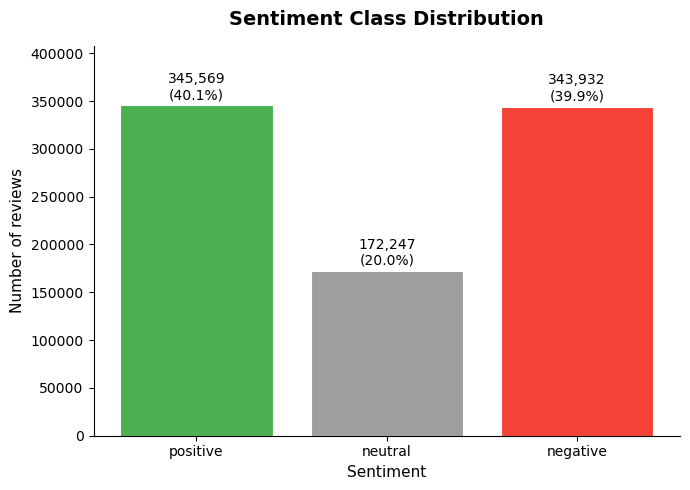

In [14]:
def plot_class_imbalance(df):
    counts = df["sentiment"].value_counts().reindex(["positive", "neutral", "negative"])
    total = counts.sum()

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ["#4CAF50", "#9E9E9E", "#F44336"]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)

    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.004,
            f"{count:,}\n({count / total * 100:.1f}%)",
            ha="center", va="bottom", fontsize=10,
        )

    ax.set_title("Sentiment Class Distribution", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Sentiment", fontsize=11)
    ax.set_ylabel("Number of reviews", fontsize=11)
    ax.set_ylim(0, counts.max() * 1.18)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    output_dir = PROJECT_ROOT / "analysis_output"
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / "class_imbalance.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved to {output_path}")
    plt.show()


plot_class_imbalance(df)

### Train / test split

In [15]:
def split_dataset(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
) -> tuple:
    print(f"Splitting dataset — test size: {test_size:.0%}, random_state: {random_state}")
    df_train, df_test = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df["sentiment"]
    )
    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    print(f"  Train : {len(df_train):,} rows")
    print(f"  Test  : {len(df_test):,} rows")
    print("Test set distribution (realistic, kept imbalanced):")
    test_counts = df_test["sentiment"].value_counts()
    total_test = len(df_test)
    for cls in ["positive", "neutral", "negative"]:
        n = test_counts.get(cls, 0)
        print(f"  {cls}: {n:,} ({n / total_test * 100:.1f}%)")
    print()
    return df_train, df_test


df_train, df_test = split_dataset(df)

Splitting dataset — test size: 20%, random_state: 42
  Train : 689,398 rows
  Test  : 172,350 rows
Test set distribution (realistic, kept imbalanced):
  positive: 69,114 (40.1%)
  neutral: 34,449 (20.0%)
  negative: 68,787 (39.9%)



### Training set balancing

In [16]:
def balance_training_set(
    df_train: pd.DataFrame,
    n_per_class: int,
    random_state: int = 42,
) -> pd.DataFrame:
    classes = ["positive", "neutral", "negative"]

    print(f"Balancing training set — target: {n_per_class:,} rows per class.")
    print("Before:")
    counts_before = df_train["sentiment"].value_counts()
    for cls in classes:
        print(f"  {cls}: {counts_before.get(cls, 0):,}")

    samples = []
    for cls in classes:
        cls_df = df_train[df_train["sentiment"] == cls]
        available = len(cls_df)
        n = min(n_per_class, available)
        if available < n_per_class:
            print(f"Warning: '{cls}' has only {available:,} rows — using all available.")
        samples.append(cls_df.sample(n=n, random_state=random_state))

    df_balanced = (
        pd.concat(samples)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    print("\nAfter:")
    counts_after = df_balanced["sentiment"].value_counts()
    for cls in classes:
        print(f"  {cls}: {counts_after.get(cls, 0):,}")
    print(f"Total training rows: {len(df_balanced):,}\n")

    return df_balanced


df_train = balance_training_set(df_train, SAMPLES_PER_CLASS)

Balancing training set — target: 5,000 rows per class.
Before:
  positive: 276,455
  neutral: 137,798
  negative: 275,145

After:
  positive: 5,000
  neutral: 5,000
  negative: 5,000
Total training rows: 15,000



---

### Baseline model — TF-IDF + logistic regression

This baseline serves as a **cheap reference point**: if DistilBERT does not clearly outperform it, the added cost and complexity of a transformer are not justified.

**Why TF-IDF + logistic regression?** TF-IDF produces sparse, high-dimensional feature vectors — a representation that suits linear classifiers well, since logistic regression converges quickly and remains interpretable. The known weakness of this pairing is its **bag-of-words assumption**: word order is discarded, so negation (*"not good"*) and sarcasm (*"great quality, broke in a day"*) are likely failure cases — exactly the signal DistilBERT's attention mechanism is built to capture.

In [17]:
def train_baseline(X_train, y_train):
    """Fit a TF-IDF vectorizer and logistic regression on the training set.

    The vectorizer is fitted on training text only to prevent data leakage.
    No evaluation is performed — return the fitted objects for later use.

    Parameters:
        X_train (list[str]): Training review texts.
        y_train (list[str]): Training sentiment labels.

    Returns:
        tuple[TfidfVectorizer, LogisticRegression]: Fitted vectorizer and classifier.
    """
    print("Training baseline model — TF-IDF + logistic regression")

    vectorizer = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        stop_words="english",
    )
    X_tfidf = vectorizer.fit_transform(X_train)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tfidf, y_train)

    print(f"  Vocabulary size : {len(vectorizer.vocabulary_):,}")
    print(f"  Training samples: {len(X_train):,}\n")
    return vectorizer, model


vectorizer_baseline, model_baseline = train_baseline(
    df_train["text"].tolist(), df_train["sentiment"].tolist()
)

Training baseline model — TF-IDF + logistic regression
  Vocabulary size : 10,000
  Training samples: 15,000



In [18]:
def predict_baseline(vectorizer, model, texts):
    """Transform texts with the fitted vectorizer and return model predictions.

    Parameters:
        vectorizer (TfidfVectorizer): Fitted TF-IDF vectorizer.
        model (LogisticRegression): Fitted logistic regression classifier.
        texts (list[str]): Review texts to classify.

    Returns:
        list[str]: Predicted sentiment labels ('positive', 'neutral', 'negative').
    """
    return model.predict(vectorizer.transform(texts))


baseline_preds = predict_baseline(vectorizer_baseline, model_baseline, df_test["text"].tolist())
print(f"Predictions stored — {len(baseline_preds):,} test samples ready for evaluation.")

Predictions stored — 172,350 test samples ready for evaluation.


### Champion model — DistilBERT fine-tuning

Unlike the bag-of-words baseline, a transformer reads **word order**: its self-attention layers can link *"not"* to the adjective it modifies and detect sarcasm patterns that span several words. DistilBERT was pre-trained on a large English corpus, so it already knows the language — fine-tuning on our 5 k/class training set only adapts the classification head and the upper attention layers to three sentiment labels, which is why so little labelled data is sufficient.

In [ ]:
class _SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def train_distilbert(X_train, y_train, X_val, y_val, device, save_dir=MODEL_SAVE_DIR):
    """Fine-tune DistilBERT for 3-class sentiment classification.

    Parameters:
        X_train (list[str]): Training review texts.
        y_train (list[str]): Training sentiment labels (string).
        X_val (list[str]): Validation review texts.
        y_val (list[str]): Validation sentiment labels (string).
        device (torch.device): Compute device (mps, cuda, or cpu).
        save_dir (str): Directory to save the fine-tuned model and tokenizer.

    Returns:
        tuple[DistilBertForSequenceClassification, DistilBertTokenizerFast]:
            Fine-tuned model and tokenizer.
    """
    print("Training champion model — DistilBERT fine-tuning")

    tokenizer = DistilBertTokenizerFast.from_pretrained(DISTILBERT_MODEL)
    model = DistilBertForSequenceClassification.from_pretrained(
        DISTILBERT_MODEL, num_labels=3
    )
    model.to(device)
    print(f"  Model is on device: {next(model.parameters()).device}")

    y_train_ids = [LABEL_TO_ID[label] for label in y_train]
    y_val_ids = [LABEL_TO_ID[label] for label in y_val]

    train_encodings = tokenizer(
        X_train, truncation=True, padding=True, max_length=MAX_TOKEN_LENGTH
    )
    val_encodings = tokenizer(
        X_val, truncation=True, padding=True, max_length=MAX_TOKEN_LENGTH
    )

    train_dataset = _SentimentDataset(train_encodings, y_train_ids)
    val_dataset = _SentimentDataset(val_encodings, y_val_ids)

    training_args = TrainingArguments(
        output_dir="./distilbert_output",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy="epoch",
        seed=RANDOM_STATE,
        report_to="none",
        logging_strategy="steps",
        logging_steps=50,
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    start = time.time()
    trainer.train()
    elapsed_minutes = (time.time() - start) / 60
    print(f"\n{'='*50}\nTraining completed in {elapsed_minutes:.1f} minutes\n{'='*50}")

    Path(save_dir).mkdir(parents=True, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"  Model and tokenizer saved to: {save_dir}\n")

    return model, tokenizer

In [ ]:
def predict_distilbert(model, tokenizer, texts, device):
    """Run batched inference with the fine-tuned DistilBERT model.

    Parameters:
        model (DistilBertForSequenceClassification): Fine-tuned classification model.
        tokenizer (DistilBertTokenizerFast): Tokenizer matched to the model.
        texts (list[str]): Review texts to classify.
        device (torch.device): Compute device (mps, cuda, or cpu).

    Returns:
        list[str]: Predicted sentiment labels ('positive', 'neutral', 'negative').
    """
    model.eval()
    all_preds = []

    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]
        encodings = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_TOKEN_LENGTH,
            return_tensors="pt",
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            logits = model(**encodings).logits
        all_preds.extend(logits.argmax(dim=-1).tolist())

    return [ID_TO_LABEL[i] for i in all_preds]

### Model persistence — save and load

After fine-tuning we save the model and tokenizer to `MODEL_SAVE_DIR` (default `saved_model/`).  This serves two purposes:

- **Reuse without retraining** — evaluation and the Gradio UI can call `load_distilbert()` to restore the exact same weights in seconds instead of running the ~18-minute fine-tune again.
- **Colab session persistence** — by passing a Google Drive path (e.g. `/content/drive/MyDrive/saved_model`) as `save_dir`, the model survives runtime restarts. Pass the same path to `load_distilbert()` to reload it in a fresh session.

In [ ]:
def load_distilbert(save_dir, device):
    """Load a fine-tuned DistilBERT model and tokenizer from disk.

    Parameters:
        save_dir (str): Directory containing the saved model and tokenizer.
        device (torch.device): Compute device to move the model to.

    Returns:
        tuple[DistilBertForSequenceClassification, DistilBertTokenizerFast]:
            Loaded model (in eval mode) and tokenizer.
    """
    print(f"Loading DistilBERT model from: {save_dir}")
    tokenizer = DistilBertTokenizerFast.from_pretrained(save_dir)
    model = DistilBertForSequenceClassification.from_pretrained(save_dir)
    model.to(device)
    model.eval()
    print(f"  Model is on device: {next(model.parameters()).device}\n")
    return model, tokenizer

In [ ]:
df_bert_train, df_bert_val = train_test_split(
    df_train,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=df_train["sentiment"],
)

model_distilbert, tokenizer = train_distilbert(
    df_bert_train["text"].tolist(),
    df_bert_train["sentiment"].tolist(),
    df_bert_val["text"].tolist(),
    df_bert_val["sentiment"].tolist(),
    DEVICE,
)

distilbert_preds = predict_distilbert(
    model_distilbert, tokenizer, df_test["text"].tolist(), DEVICE
)
print(f"Predictions stored — {len(distilbert_preds):,} test samples ready for evaluation.")

---

### Evaluation — baseline vs. champion

Both models are scored with **identical code on the same test set** — the only fair basis for comparison.

**Why macro-F1 is the headline metric:** The test set is class-imbalanced (~40% positive, 20% neutral, 40% negative). Accuracy alone can mask poor performance on minority classes — a model that ignores neutral entirely could still score above 80%. Macro-F1 gives each class equal weight regardless of frequency, so a high score means the model genuinely handles all three sentiments.

**Why the confusion matrix complements aggregate scores:** A single F1 number tells you *how many* errors were made; the matrix shows *which errors* — for instance, whether the model confuses neutral with positive, or negative with neutral. That directional information is essential for deciding whether the model is production-ready.

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    """Compute accuracy, macro-F1, and a full per-class classification report.

    Parameters:
        y_true (list[str]): True sentiment labels from the test set.
        y_pred (list[str]): Predicted labels returned by predict_baseline or
            predict_distilbert.
        model_name (str): Display name printed in the report header
            (e.g. "TF-IDF Baseline", "DistilBERT Champion").

    Returns:
        dict | None: Keys 'accuracy', 'macro_f1', and 'report', or None on error.
    """
    print(f"Evaluating {model_name}")
    try:
        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")  # primary metric
        report = classification_report(
            y_true,
            y_pred,
            labels=["negative", "neutral", "positive"],
            digits=4,
        )

        print(f"\n{'='*50}")
        print(f"  {model_name}")
        print(f"{'='*50}")
        print(f"  Accuracy : {accuracy:.4f}")
        print(f"  Macro-F1 : {macro_f1:.4f}  ← primary metric")
        print(f"\n{report}")

        return {"accuracy": accuracy, "macro_f1": macro_f1, "report": report}
    except Exception as e:
        print(f"  Error evaluating {model_name}: {e}")
        return None

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot and save a labelled confusion matrix as a seaborn heatmap.

    Parameters:
        y_true (list[str]): True sentiment labels.
        y_pred (list[str]): Predicted sentiment labels.
        model_name (str): Used in the plot title and output filename.

    Returns:
        None
    """
    print(f"Plotting confusion matrix — {model_name}")
    try:
        labels = ["negative", "neutral", "positive"]
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_title(
            f"Confusion Matrix — {model_name}",
            fontsize=14,
            fontweight="bold",
            pad=15,
        )
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("Actual", fontsize=11)
        plt.tight_layout()

        output_dir = PROJECT_ROOT / "analysis_output"
        output_dir.mkdir(exist_ok=True)
        filename = f"{model_name.replace(' ', '_')}_confusion_matrix.png"
        output_path = output_dir / filename
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Confusion matrix saved to: {output_path}")
    except Exception as e:
        print(f"  Error plotting confusion matrix for {model_name}: {e}")

In [ ]:
y_true = df_test["sentiment"].tolist()

metrics_baseline = evaluate_model(y_true, baseline_preds, "TF-IDF Baseline")
plot_confusion_matrix(y_true, baseline_preds, "TF-IDF Baseline")

metrics_distilbert = evaluate_model(y_true, distilbert_preds, "DistilBERT Champion")
plot_confusion_matrix(y_true, distilbert_preds, "DistilBERT Champion")

sep = "═" * 40
print(f"\n{sep}\nMODEL COMPARISON SUMMARY\n{sep}")
print(f"{'':16}  Accuracy  Macro-F1")
if metrics_baseline:
    print(f"{'TF-IDF Baseline':<16}:  {metrics_baseline['accuracy']:.4f}    {metrics_baseline['macro_f1']:.4f}")
if metrics_distilbert:
    print(f"{'DistilBERT':<16}:  {metrics_distilbert['accuracy']:.4f}    {metrics_distilbert['macro_f1']:.4f}")
print(sep)